In [2]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import f1_score


df = pd.read_csv('finaldataset_with_sets.csv')

def views_to_class(views):
    if views < 10000:
        return 0
    elif 10000 <= views < 100000:
        return 1
    elif 100000 <= views < 500000:
        return 2
    elif 500000 <= views < 1000000:
        return 3
    else:
        return 4

df['label'] = df['views'].apply(views_to_class)

df.to_csv('finaldataset_with_sets.csv', index=False)

# Split into train and validation sets
train_df = df[df['set'] == 'training']
val_df = df[df['set'] == 'validation']


In [3]:
# Load processed features 
def load_features(video_id, feature_dir='processedfeatures_final'):
    return np.load(f'{feature_dir}/{video_id}_corrected_features.npy')

# Load features for training and validation sets
train_features = np.array([load_features(video_id) for video_id in train_df['video_id']])
val_features = np.array([load_features(video_id) for video_id in val_df['video_id']])

# Convert labels to tensors
train_labels = torch.tensor(train_df['label'].values, dtype=torch.long)
val_labels = torch.tensor(val_df['label'].values, dtype=torch.long)

# Convert features to tensors
train_features = torch.tensor(train_features, dtype=torch.float32)
val_features = torch.tensor(val_features, dtype=torch.float32)


In [5]:
class CNNRNNModel(nn.Module):
    def __init__(self, input_dim=512, hidden_dim=128, num_classes=5, num_layers=3):
        super(CNNRNNModel, self).__init__()
        self.rnn = nn.GRU(input_size=input_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        out, _ = self.rnn(x)  
        out = self.fc(out)  
        out = torch.mean(out, dim=1)  
        return out


In [6]:
model = CNNRNNModel(input_dim=512, hidden_dim=128, num_classes=5, num_layers=3)

### Grad-CAM++ at Late-Fusion Level

In [11]:
import pandas as pd
import torch
import torch.nn as nn
from transformers import BertTokenizer, BertModel, AdamW, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
class TextClassificationModel(nn.Module):
    def __init__(self, num_classes=5, dropout_rate=0.5):
        super(TextClassificationModel, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(self.bert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs[1]  # CLS token
        dropout_output = self.dropout(pooled_output)
        return self.fc(dropout_output)
        
text_model = TextClassificationModel(num_classes=5, dropout_rate=0.5).to(device)
num_classes = 5 
text_model = TextClassificationModel(num_classes=num_classes)

# Load the state dictionary
text_model.load_state_dict(torch.load('text_model_final3.pth'))

# Set the model to evaluation mode
text_model.eval()


A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Pl

TextClassificationModel(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, e

In [13]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(text):
    return tokenizer(text, padding='max_length', truncation=True, return_tensors="pt")

df['input_ids'] = df['transcript'].apply(lambda x: tokenize_function(x)['input_ids'].squeeze())
df['attention_mask'] = df['transcript'].apply(lambda x: tokenize_function(x)['attention_mask'].squeeze())

/opt/anaconda3/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [15]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import cv2


resnet_model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
resnet_model.fc = nn.Identity()  # model up to the final convolutional layer
resnet_model.eval()

class AttentionFusion(nn.Module):
    def __init__(self, input_dim):
        super(AttentionFusion, self).__init__()
        self.fc_text = nn.Linear(input_dim, 1)
        self.fc_visual = nn.Linear(input_dim, 1)

    def forward(self, text_logits, visual_logits):
        if isinstance(text_logits, np.ndarray):
            text_logits = torch.tensor(text_logits).float()
        if isinstance(visual_logits, np.ndarray):
            visual_logits = torch.tensor(visual_logits).float()
        text_weight = torch.softmax(self.fc_text(text_logits), dim=1)
        visual_weight = torch.softmax(self.fc_visual(visual_logits), dim=1)
        weighted_text_logits = text_weight * text_logits
        weighted_visual_logits = visual_weight * visual_logits

# Combine the logits
        fused_logits = weighted_text_logits + weighted_visual_logits
        return fused_logits

# Initialize the fusion model
fusion_model = AttentionFusion(input_dim=5)  
fusion_model.eval()

# Preprocessing the input image
def preprocess_image(image_path):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    image = Image.open(image_path).convert("RGB")
    return transform(image).unsqueeze(0), image

def apply_gradcam_plus_plus_late_fusion(resnet_model, text_model, rnn_model, fusion_model, input_tensor, text_input, target_class):
    # Get features from ResNet
    features = resnet_model(input_tensor)
    features_for_rnn = features.unsqueeze(1)

    # Generate text logits using the text model
    text_outputs = text_model(input_ids=text_input['input_ids'], attention_mask=text_input['attention_mask'])
    text_logits = text_outputs.detach()

    # Generate visual logits using the RNN model
    visual_logits = rnn_model(features_for_rnn).detach()

    # Pass both logits to the AttentionFusion model
    fused_logits = fusion_model(text_logits, visual_logits)
    predicted_class = torch.argmax(fused_logits, dim=1).item()

    # Generate Grad-CAM++ heatmap for visualization
    cam = GradCAMPlusPlus(model=resnet_model, target_layers=[resnet_model.layer4[-1]])
    target = ClassifierOutputTarget(target_class)
    grayscale_cam = cam(input_tensor=input_tensor, targets=[target])[0]

    return grayscale_cam, predicted_class



/var/folders/_8/94fj1n4s1ns_1npfkgrt_ll40000gn/T/ipykernel_71393/3122634703.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids = torch.tensor(video_row['input_ids'].values[0], dtype=torch.long).unsqueeze(0)
/var/folders/_8/94fj1n4s1ns_1npfkgrt_ll40000gn/T/ipykernel_71393/3122634703.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  attention_mask = torch.tensor(video_row['attention_mask'].values[0], dtype=torch.long).unsqueeze(0)


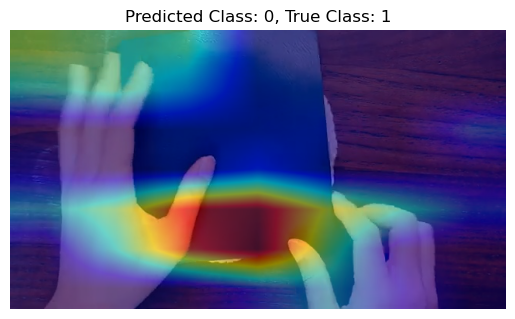

In [43]:
def get_true_class(video_id):
    match = df[df['video_id'] == video_id]
    if not match.empty:
        return match['label'].values[0]
    else:
        raise ValueError(f"Video ID {video_id} not found in the dataset.")

image_path = "validation_frames/O275Bq0LCpI/frame_0850.jpg"
video_id = "O275Bq0LCpI"
input_tensor, input_image = preprocess_image(image_path)

video_row = df[df['video_id'] == video_id]                                             

input_ids = torch.tensor(video_row['input_ids'].values[0], dtype=torch.long).unsqueeze(0)
attention_mask = torch.tensor(video_row['attention_mask'].values[0], dtype=torch.long).unsqueeze(0)

text_input = {
    'input_ids': input_ids,
    'attention_mask': attention_mask
}

true_class = get_true_class(video_id)
target_class = get_true_class(video_id)
grayscale_cam, predicted_class = apply_gradcam_plus_plus_late_fusion(
    resnet_model, text_model, model, fusion_model, input_tensor, text_input, target_class
)

grayscale_cam_resized = cv2.resize(grayscale_cam, (input_image.size[0], input_image.size[1]))

cam_image = show_cam_on_image(np.array(input_image) / 255.0, grayscale_cam_resized, use_rgb=True)

# Visualize the result
plt.imshow(cam_image)
plt.title(f"Predicted Class: {predicted_class}, True Class: {true_class}")
plt.axis('off')
plt.show()
